In [1]:
import os as os
import sys
import importlib
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig
from scipy.signal import get_window
from gwpy.timeseries import TimeSeriesDict
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

# adding folders to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd()  , '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

akshat_lisa_root = os.path.abspath(os.path.join(os.getcwd()  , '..',))
if akshat_lisa_root not in sys.path:
    sys.path.insert(0, akshat_lisa_root)


from psd_estimation_methods.wosa import wosa
from psd_estimation_methods.lpsd import lpsd, lpsd_wosa
from psd_estimation_methods.logpsd import logpsd
from scripts.plot import plot, plot_segments
from scripts.readTdi import readTdi, getTdiPath
from scripts.psdNoise import n_time_noise_from_psd, n_noise_psds, compute_psd_noise_distribution, normalized_psd_residual
plt.rcParams['text.usetex'] = False


/Users/akmdgreat/anaconda3/envs/bethenv/lib/python3.11/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


['L_1', 'L_1', '(0.6)^1 L_1', '(0.6)^2 L_1', '(0.6)^3 L_1', '(0.6)^4 L_1', '(0.6)^5 L_1', '(0.6)^6 L_1', '(0.6)^7 L_1', '(0.6)^8 L_1', '(0.6)^9 L_1', '(0.6)^10 L_1', '(0.6)^11 L_1', '(0.6)^12 L_1', '(0.6)^13 L_1', '(0.6)^14 L_1', '(0.6)^15 L_1']
Lk_list: [17200, 17200, 10320, 6192, 3715, 2229, 1337, 802, 481, 288, 173, 104, 62, 37, 22, 13]
fk_list: [4.651162790697674e-05, 4.651162790697674e-05, 7.751937984496124e-05, 0.00012919896640826872, 0.00021534320323014804, 0.0003589053387169134, 0.0005983545250560958, 0.000997506234413965, 0.0016632016632016633, 0.002777777777777778, 0.004624277456647399, 0.007692307692307693, 0.012903225806451613, 0.021621621621621623, 0.03636363636363636, 0.06153846153846154]


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

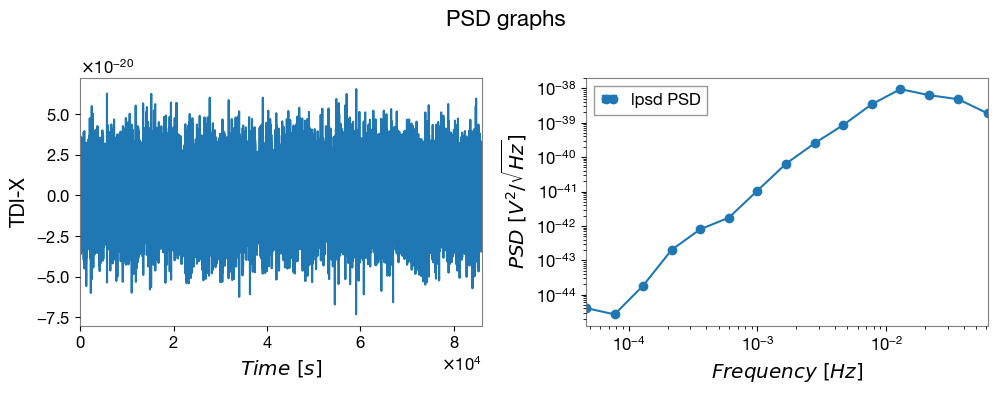

In [2]:
# 1) Read the TDI time series
tdi_path = getTdiPath('glitch_1.h5')
data_orig, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 2000
f_orig, psd_orig, _, _ = wosa(
    x=data_orig,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

f_orig_logpsd, psd_orig_logpsd, _ = logpsd(
    x=data_orig, 
    fs=fs, 
    overlap=0, 
    L1=17200
)

f_median, psd_median, _, _ = wosa(
    x=data_orig,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 

# # Plot the original psd for no reason 
# plot(
#     data=data_orig,
#     t=t, 
#     f=f_orig, 
#     psd= [psd_orig, psd_median],
#     labels= ["mean PSD", "median PSD"],
#     title="TDI-X", 
#     bigtitle="PSD graphs",
#     f_lims = [(fs / nperseg), (fs / 2.0)]
# )

# plot(
#     data=data_orig,
#     t=t, 
#     f=f_orig, 
#     psd= [psd_orig, psd_median],
#     labels= ["mean PSD", "median PSD"],
#     title="TDI-X", 
#     bigtitle="PSD graphs",
#     f_lims = [(fs / nperseg), f_orig[-1]]
# )

plot(
    data=data_orig,
    t=t, 
    f=f_orig_logpsd, 
    psd= [psd_orig_logpsd],
    labels= ["lpsd PSD"],
    title="TDI-X", 
    bigtitle="PSD graphs",
    f_lims = [f_orig_logpsd[0], f_orig_logpsd[-1]],
    logpsd=True
)

In [3]:
f_orig_lpsd, psd_orig_lpsd, _, _ = lpsd(
    x=data_orig,
    fs=fs,
    fmin=fs/len(data_orig), 
    fmax=fs/2,
    Kdes = 100,
    Kmin = 1
)

f_orig_lpsd_2, psd_orig_lpsd_2, _, _ = lpsd_wosa(
    x=data_orig, 
    fs=fs,
    fmin=fs/len(data_orig), 
    fmax=fs/2,
    W_des=100, 
    W_min=1, 
    xi=0.5,
    Jdes=1000,
    wosa_kwargs=dict(method="mean")   # whatever options your wosa supports
)

psd_median = [7.97520349e-39 7.78689228e-39 1.01735287e-38 6.64586865e-39
 7.79215954e-39 8.08774505e-39 4.66826124e-39 4.14470501e-39
 7.59742185e-39 5.27720131e-39 7.87058468e-39 5.99997039e-39
 9.77462710e-39 1.40411480e-38 8.68047057e-39 5.19077873e-39
 4.38001547e-39 6.26168334e-39 7.20997738e-39 4.46757475e-39]
psd_out = [9.17153391e-39 8.97424707e-39 1.07506789e-38 6.13306257e-39
 7.51376130e-39 8.11862521e-39 5.99396052e-39 5.80520024e-39
 7.28047343e-39 5.85086720e-39 7.31796739e-39 7.30032897e-39
 1.05179235e-38 1.20326657e-38 8.62216024e-39 6.40659010e-39
 5.23342942e-39 7.05839328e-39 8.44246889e-39 7.65011433e-39]
Number of segments = 16


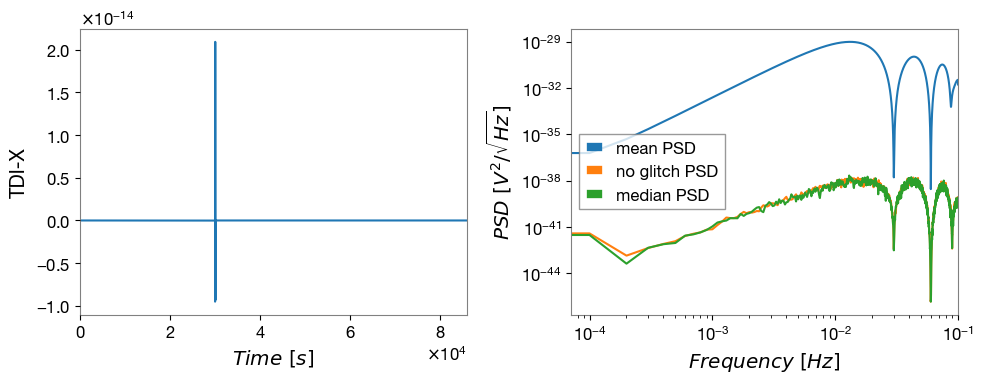

In [14]:
# list of your four datasets
file_list = [
    'glitch_9_one_day.h5'
]

nperseg = 2000

for fname in file_list:
    # load
    tdi_path = getTdiPath(fname)
    data, fs, t = readTdi(tdi_path)

    # if you need idx again
    delta_t = 1 / fs
    idx     = nperseg / delta_t

    
    f_mean, psd_mean, _, nseg = wosa(
        x=data,
        fs=fs,
        nperseg=nperseg,
        method="mean"
    )

   
    f_median, psd_median, _, _ = wosa(
        x=data,
        fs=fs,
        nperseg=nperseg,
        method="median"
    )

    f_out, psd_out, _, _ = wosa(
        x=data,
        fs=fs,
        nperseg=nperseg,
        method="outlier_rejection"
    )
    print(f"psd_median = {psd_median[200: 220]}")
    print(f"psd_out = {psd_out[200: 220]}")

    # plot all three curves (assuming psd_orig is defined)
    plot(
        data=data,
        t=t,
        f=f_mean,
        psd=[
            psd_mean, 
            psd_orig ,
            psd_median, 
            # psd_out
        ],
        labels=[
            "mean PSD", 
            "no glitch PSD" , 
            "median PSD", 
            # "outlier"
        ],
        title=f"TDI-X",
        f_lims=[f_mean[0], f_mean[-1]]
    )

print(f"Number of segments = {nseg[0]}")

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

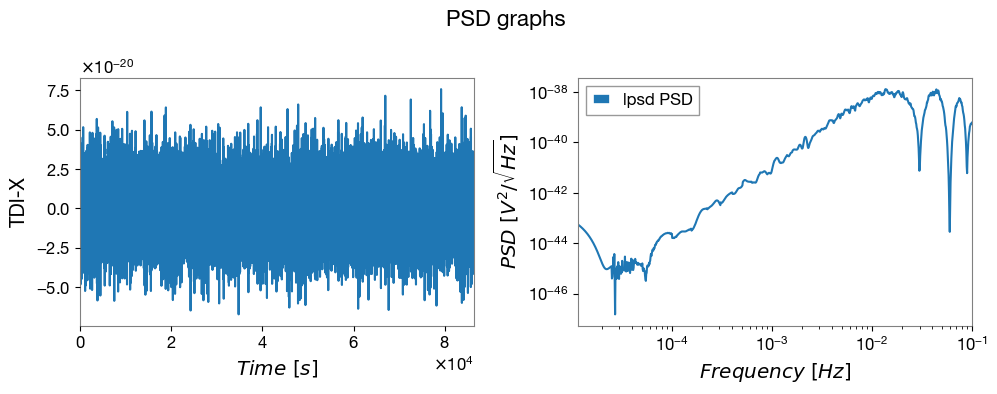

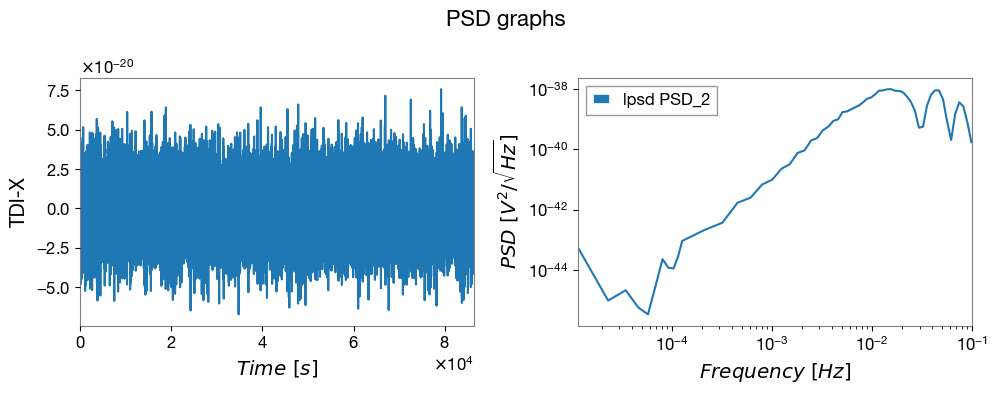

In [4]:
plot(
    data=data_orig,
    t=t, 
    f=f_orig_lpsd, 
    psd= [psd_orig_lpsd],
    labels= ["lpsd PSD"],
    title="TDI-X", 
    bigtitle="PSD graphs",
    f_lims = [f_orig_lpsd[0], (fs / 2.0)]
)

plot(
    data=data_orig,
    t=t, 
    f=f_orig_lpsd_2, 
    psd= [psd_orig_lpsd_2],
    labels= ["lpsd PSD_2"],
    title="TDI-X", 
    bigtitle="PSD graphs",
    f_lims = [f_orig_lpsd_2[0], (fs / 2.0)]
)

In [10]:
print(psd_orig_lpsd)
print(psd_orig_lpsd.size)

[5.45164734e-44 5.30290128e-44 5.15514258e-44 ... 5.28676410e-40
 5.70673066e-40 5.95386007e-40]
1000


In [11]:
print(f_orig_lpsd_2)
print(f_orig_lpsd_2.size)

[1.15740741e-05 2.31481481e-05 3.47222222e-05 4.62962963e-05
 5.78703704e-05 6.94444444e-05 8.10185185e-05 9.25925926e-05
 1.04166667e-04 1.15740741e-04 1.27314815e-04 2.11809956e-04
 3.20801782e-04 4.54939944e-04 6.14684353e-04 8.00385375e-04
 1.01224978e-03 1.25062880e-03 1.51552947e-03 1.80707466e-03
 2.12554599e-03 2.47096914e-03 2.84340862e-03 3.24261021e-03
 3.66904944e-03 4.12256418e-03 4.60333341e-03 5.11223927e-03
 5.64843230e-03 6.21181258e-03 6.80882750e-03 7.46242227e-03
 8.17926815e-03 8.96358188e-03 9.82565084e-03 1.07690471e-02
 1.18053165e-02 1.29416801e-02 1.41839162e-02 1.55444604e-02
 1.70369977e-02 1.86763420e-02 2.04781438e-02 2.24583418e-02
 2.46322548e-02 2.70132072e-02 2.96106098e-02 3.24677527e-02
 3.55927527e-02 3.90410285e-02 4.28146134e-02 4.69812801e-02
 5.15267346e-02 5.65267346e-02 6.20822902e-02 6.81428963e-02
 7.48095629e-02 8.22169703e-02 9.02169703e-02 9.89126225e-02]
60


In [4]:
dx = 5
no_glitch_integral = np.trapz(np.abs(data_orig[6000-20: 6000+20]), dx=dx)
print(no_glitch_integral)

1.9935007723480114e-18


psd_median = [1.56244630e-38 1.23490878e-38 8.36109140e-39 1.89578306e-38
 1.42470721e-38 6.88294008e-39 7.17318896e-39 2.76449519e-39
 6.97162665e-39 6.61300169e-39 7.40318134e-39 6.85127039e-39
 3.05324357e-39 7.45957576e-39 9.50834019e-39 1.01198613e-38
 9.86025758e-39 1.11534922e-38 1.10788060e-38 9.43129847e-39]
psd_out = [1.32265161e-35 1.27708177e-35 1.23068518e-35 1.19084267e-35
 1.14127544e-35 1.10785974e-35 1.07641156e-35 1.03490778e-35
 1.00236155e-35 9.58373301e-36 9.13518583e-36 8.80784946e-36
 8.56005206e-36 8.31118157e-36 7.88529163e-36 7.46892775e-36
 7.17857854e-36 6.88929373e-36 6.55094740e-36 6.26353232e-36]
psd_median = [1.95647045e-38 1.79139001e-38 1.30288634e-38 7.64844799e-39
 9.71589731e-39 1.37793911e-38 1.71065284e-38 8.68373983e-39
 1.26920209e-38 1.54584107e-38 1.11628481e-38 9.06846180e-39
 8.93705184e-39 1.24434993e-38 9.64446158e-39 1.03994079e-38
 9.77756966e-39 8.19738184e-39 8.29829628e-39 7.74358489e-39]
psd_out = [1.98852692e-35 1.91816575e-35 1.838

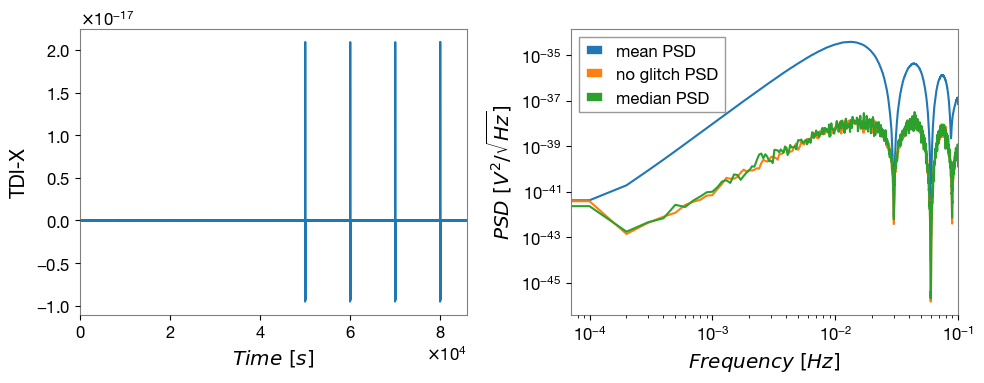

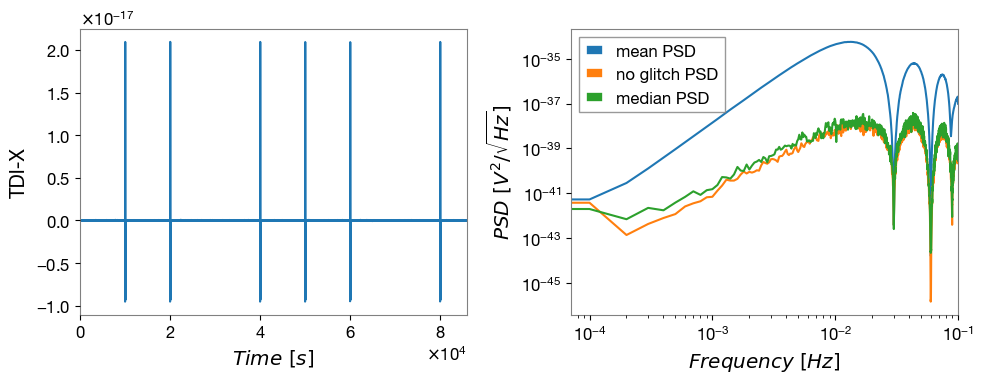

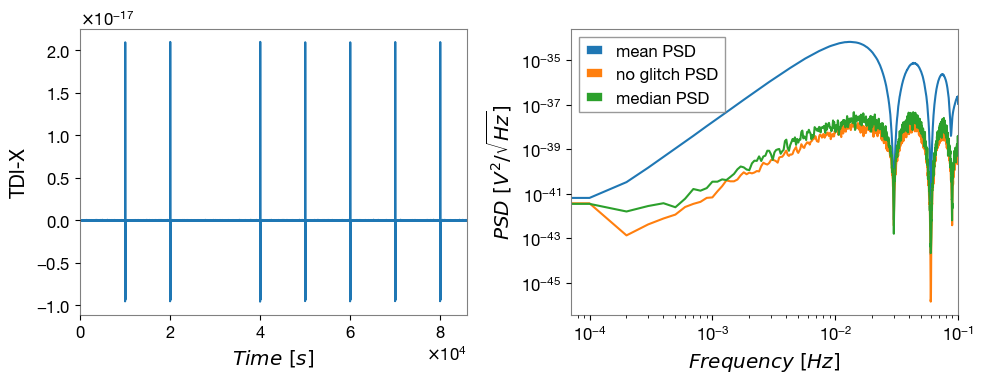

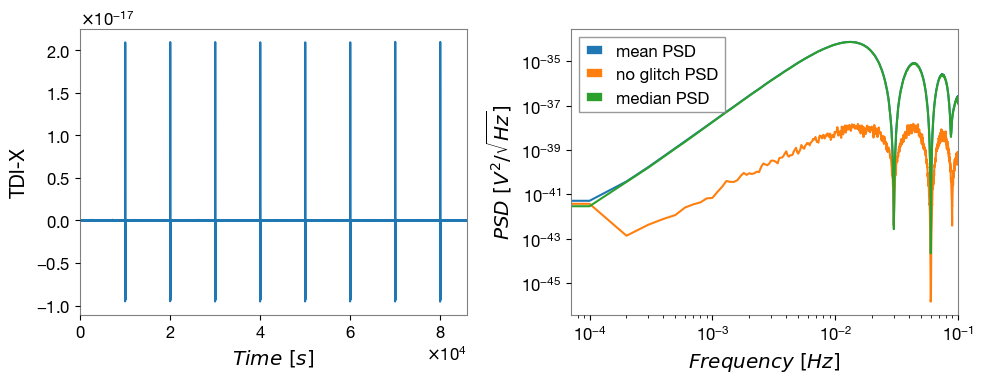

In [15]:
# list of your four datasets
file_list = [
    'glitch_7_multiple_3.h5',
    'glitch_7_multiple_4.h5',
    'glitch_7_multiple_5.h5',
    'glitch_7_multiple_2.h5'
]

nperseg = 2000

for fname in file_list:
    # load
    tdi_path = getTdiPath(fname)
    data, fs, t = readTdi(tdi_path)

    # if you need idx again
    delta_t = 1 / fs
    idx     = nperseg / delta_t

    
    f_mean, psd_mean, _, nseg = wosa(
        x=data,
        fs=fs,
        nperseg=nperseg,
        method="mean"
    )

   
    f_median, psd_median, _, _ = wosa(
        x=data,
        fs=fs,
        nperseg=nperseg,
        method="median"
    )

    f_out, psd_out, _, _ = wosa(
        x=data,
        fs=fs,
        nperseg=nperseg,
        method="outlier_rejection"
    )
    print(f"psd_median = {psd_median[200: 220]}")
    print(f"psd_out = {psd_out[200: 220]}")

    # plot all three curves (assuming psd_orig is defined)
    plot(
        data=data,
        t=t,
        f=f_mean,
        psd=[
            psd_mean, 
            psd_orig ,
            psd_median, 
            # psd_out
        ],
        labels=[
            "mean PSD", 
            "no glitch PSD" , 
            "median PSD", 
            # "outlier"
        ],
        title=f"TDI-X",
        f_lims=[f_mean[0], f_mean[-1]]
    )

print(f"Number of segments = {nseg[0]}")

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

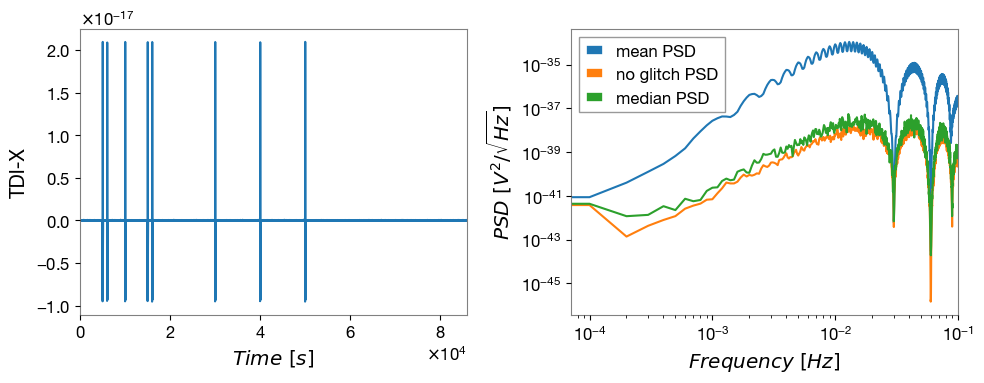

In [19]:
tdi_path = getTdiPath('glitch_7_multiple_7.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_orig, psd_median],
    labels= ["mean PSD", "no glitch PSD", "median PSD"],
    title="TDI-X", 
    f_lims = [f_mean[0], f_mean[-1]]
)



Number of segments = 33


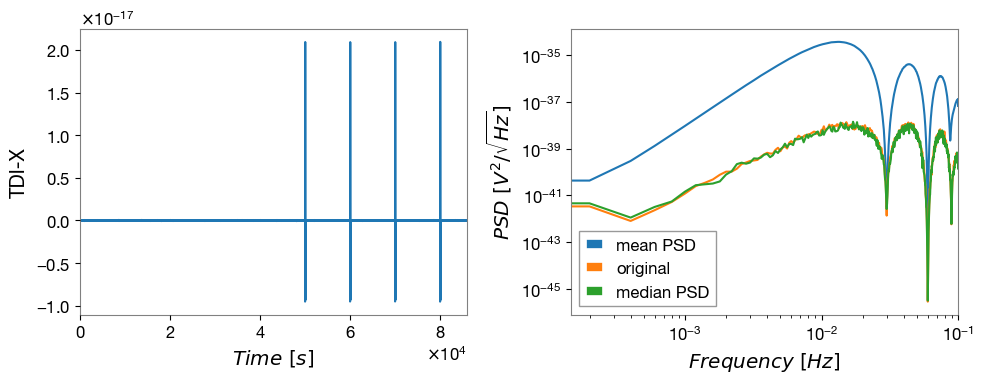

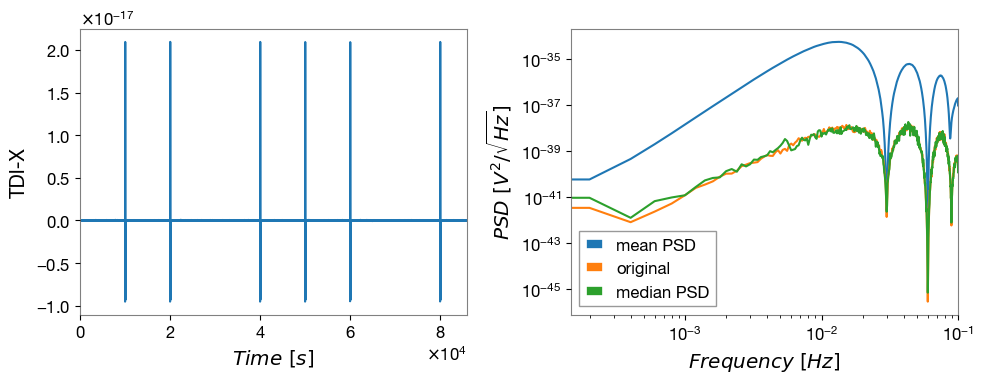

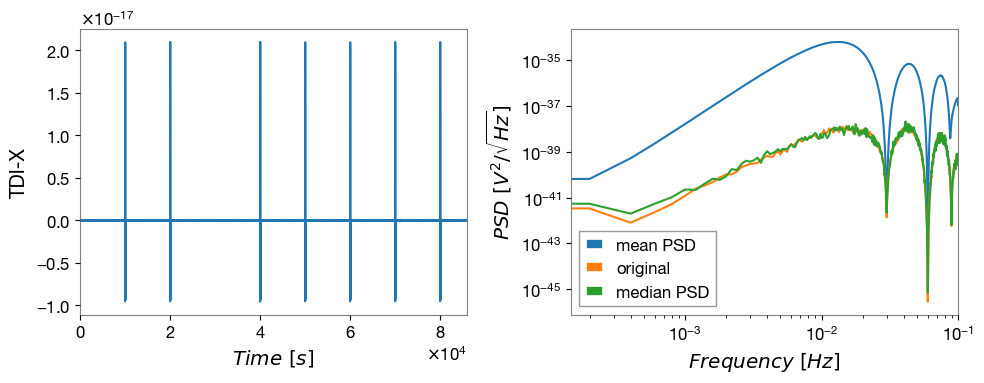

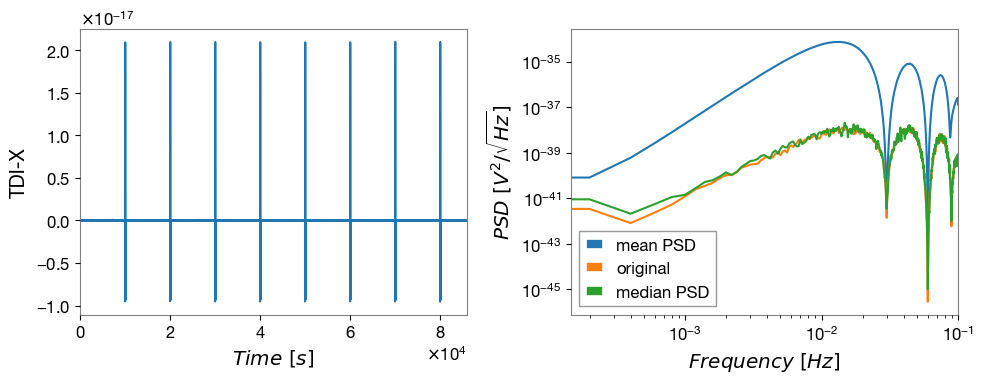

In [21]:
# 1) Read the TDI time series
tdi_path = getTdiPath('glitch_1.h5')
data_orig, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 1000
f_orig, psd_orig, _, _ = wosa(
    x=data_orig,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

# list of your four datasets
file_list = [
    'glitch_7_multiple_3.h5',
    'glitch_7_multiple_4.h5',
    'glitch_7_multiple_5.h5',
    'glitch_7_multiple_2.h5'
]

for fname in file_list:
    # load
    tdi_path = getTdiPath(fname)
    data, fs, t = readTdi(tdi_path)

    # if you need idx again
    delta_t = 1 / fs
    idx     = nperseg / delta_t

    # compute mean‐PSD (and print # segments)
    f_mean, psd_mean, _, nseg = wosa(
        x=data,
        fs=fs,
        nperseg=nperseg,
        method="mean"
    )

    # compute median‐PSD
    f_median, psd_median, _, _ = wosa(
        x=data,
        fs=fs,
        nperseg=nperseg,
        method="median"
    )

    f_out, psd_out, _, _ = wosa(
        x=data,
        fs=fs,
        nperseg=nperseg,
        method="outlier_rejection"
    )

    # plot all three curves (assuming psd_orig is defined)
    plot(
        data=data,
        t=t,
        f=f_mean,
        psd=[
            psd_mean,
            psd_orig,
            psd_median,  
            # psd_out
        ],
        labels=[
            "mean PSD",
            "original", 
            "median PSD", 
            # "outlier"
        ],
        #title=f"TDI-X ({fname})",
        title=f"TDI-X",
        f_lims=[f_mean[0], f_mean[-1]]
    )

print(f"Number of segments = {nseg[0]}")

Number of segments = 16


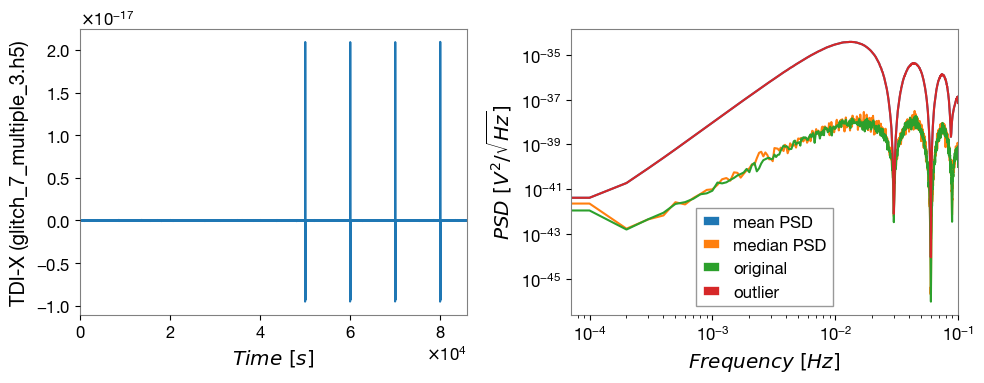

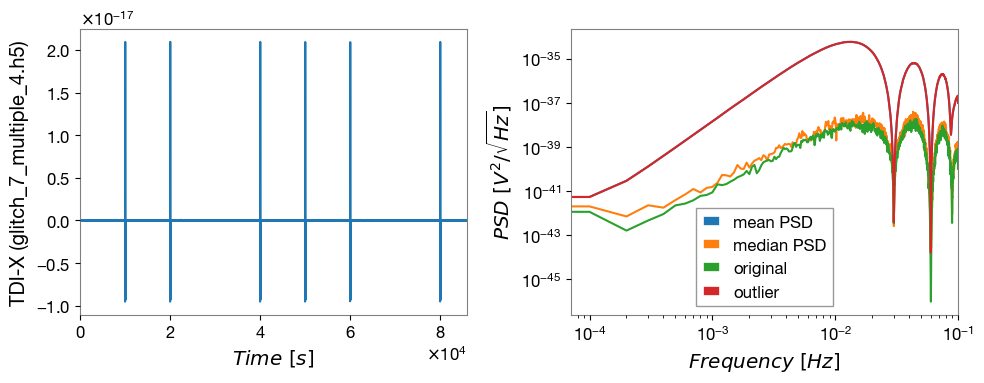

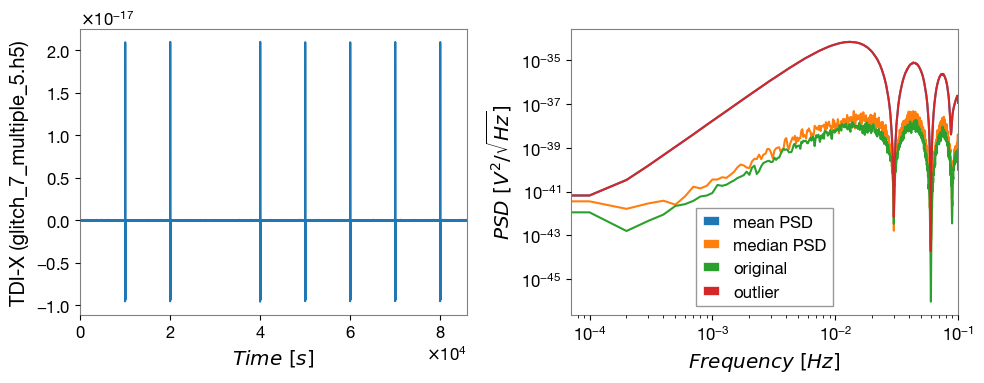

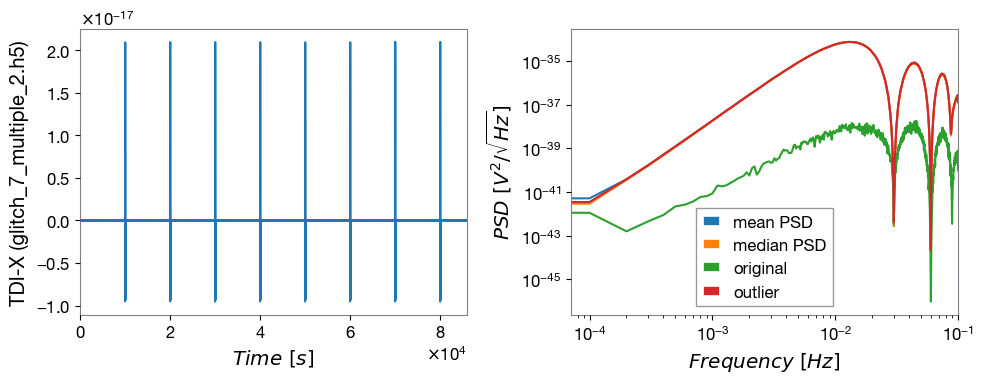

In [4]:
# list of your four datasets
file_list = [
    'glitch_7_multiple_3.h5',
    'glitch_7_multiple_4.h5',
    'glitch_7_multiple_5.h5',
    'glitch_7_multiple_2.h5'
]

nperseg = 2000

for fname in file_list:
    # load
    tdi_path = getTdiPath(fname)
    data, fs, t = readTdi(tdi_path)

    # if you need idx again
    delta_t = 1 / fs
    idx     = nperseg / delta_t

    # compute mean‐PSD (and print # segments)
    f_mean, psd_mean, _, nseg = wosa(
        x=data,
        fs=fs,
        nperseg=nperseg,
        method="mean"
    )

    # compute median‐PSD
    f_median, psd_median, _, _ = wosa(
        x=data,
        fs=fs,
        nperseg=nperseg,
        method="median"
    )

    f_out, psd_out, _, _ = wosa(
        x=data,
        fs=fs,
        nperseg=nperseg,
        method="outlier_rejection"
    )

    # plot all three curves (assuming psd_orig is defined)
    plot(
        data=data,
        t=t,
        f=f_mean,
        psd=[psd_mean, psd_median, psd_orig, psd_out],
        labels=["mean PSD", "median PSD", "original", "outlier"],
        title=f"TDI-X ({fname})",
        f_lims=[f_mean[0], f_mean[-1]]
    )

print(f"Number of segments = {nseg[0]}")

psd_median = [7.97520349e-39 7.78689228e-39 1.01735287e-38 6.64586865e-39
 7.79215954e-39 8.08774505e-39 4.66826124e-39 4.14470501e-39
 7.59742185e-39 5.27720131e-39 7.87058468e-39 5.99997039e-39
 9.77462710e-39 1.40411480e-38 8.68047057e-39 5.19077873e-39
 4.38001547e-39 6.26168334e-39 7.20997738e-39 4.46757475e-39]
psd_out = [2.69019341e-37 2.74640072e-37 2.72956808e-37 2.39518881e-37
 2.90929734e-37 2.35589913e-37 2.68566939e-37 2.27899923e-37
 2.19231686e-37 2.52028242e-37 2.10773831e-37 2.22776740e-37
 2.25658364e-37 2.20099336e-37 2.08527556e-37 1.82305413e-37
 2.10386215e-37 1.87384252e-37 1.83362604e-37 1.94185818e-37]
Number of segments = 16


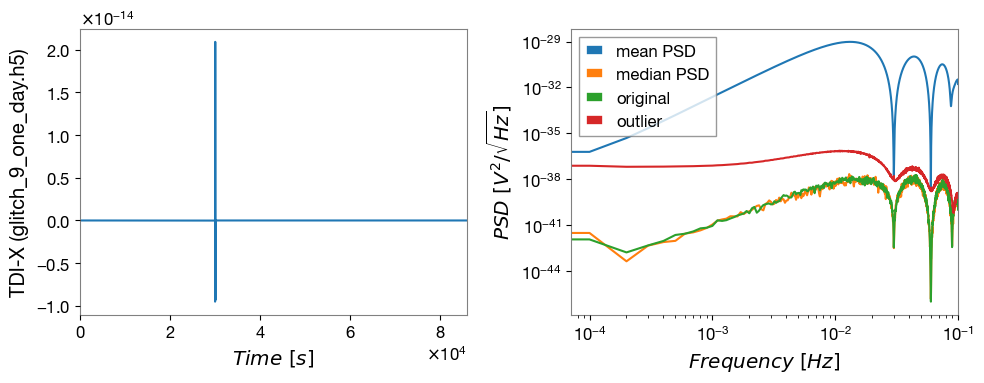

In [8]:
# list of your four datasets
file_list = [
    'glitch_9_one_day.h5'
]

nperseg = 2000

for fname in file_list:
    # load
    tdi_path = getTdiPath(fname)
    data, fs, t = readTdi(tdi_path)

    # if you need idx again
    delta_t = 1 / fs
    idx     = nperseg / delta_t

    # compute mean‐PSD (and print # segments)
    f_mean, psd_mean, _, nseg = wosa(
        x=data,
        fs=fs,
        nperseg=nperseg,
        method="mean"
    )

    # compute median‐PSD
    f_median, psd_median, _, _ = wosa(
        x=data,
        fs=fs,
        nperseg=nperseg,
        method="median"
    )

    f_out, psd_out, _, _ = wosa(
        x=data,
        fs=fs,
        nperseg=nperseg,
        method="outlier_rejection"
    )
    print(f"psd_median = {psd_median[200: 220]}")
    print(f"psd_out = {psd_out[200: 220]}")

    # plot all three curves (assuming psd_orig is defined)
    plot(
        data=data,
        t=t,
        f=f_mean,
        psd=[psd_mean, psd_median, psd_orig, psd_out],
        labels=["mean PSD", "median PSD", "original", "outlier"],
        title=f"TDI-X ({fname})",
        f_lims=[f_mean[0], f_mean[-1]]
    )

print(f"Number of segments = {nseg[0]}")

/Users/akmdgreat/anaconda3/envs/bethenv/lib/python3.11/site-packages/gwpy/plot/axes.py:78: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  return func(self, **kw)


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

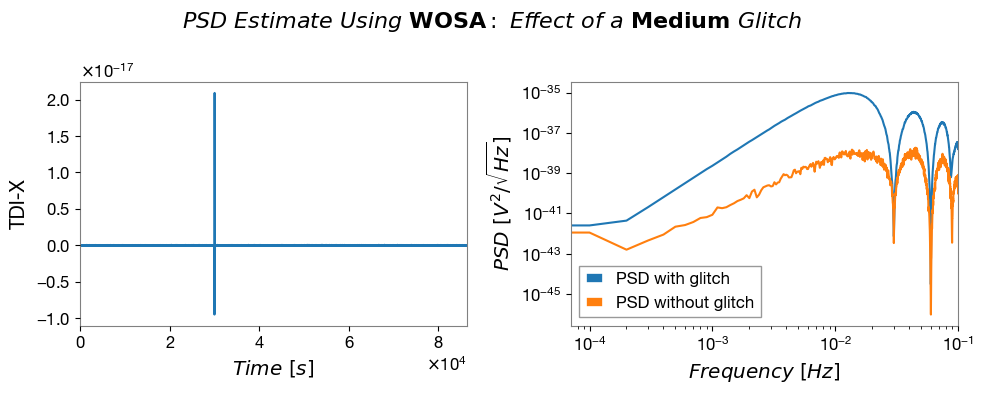

In [8]:
# 1) Read the TDI time series
tdi_path = getTdiPath('glitch_7.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 

# Plot the original psd for no reason 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_orig],
    labels= ["PSD with glitch", "PSD without glitch"],
    f_lims = [f_mean[0], f_mean[-1]],
    title="TDI-X", 
    # bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}"
    bigtitle=r"$PSD\ Estimate\ Using\ \mathbf{WOSA}:\ Effect\ of\ a\ \mathbf{Medium}\ Glitch$"
)

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

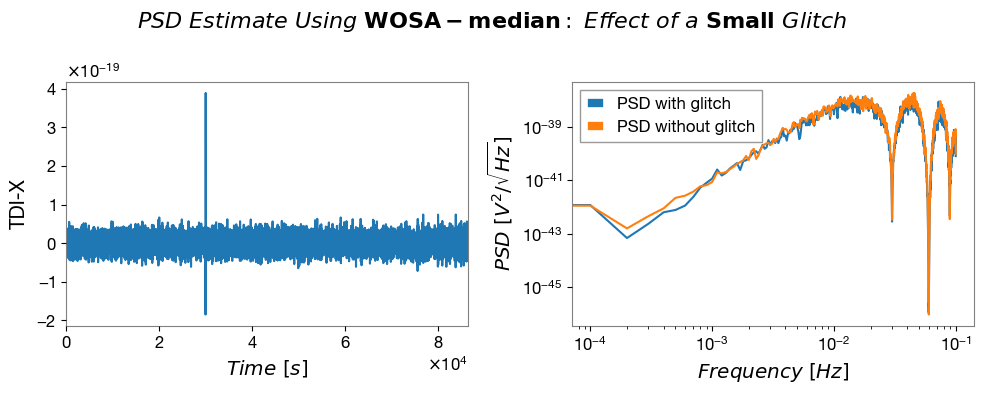

In [9]:
# 1) Read the TDI time series
tdi_path = getTdiPath('glitch_0.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 2000
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 

# Plot the original psd for no reason 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_median, psd_orig],
    labels= ["PSD with glitch", "PSD without glitch"],
    title="TDI-X", 
    # bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}"
    bigtitle=r"$PSD\ Estimate\ Using\ \mathbf{WOSA-median}:\ Effect\ of\ a\ \mathbf{Small}\ Glitch$",
)

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

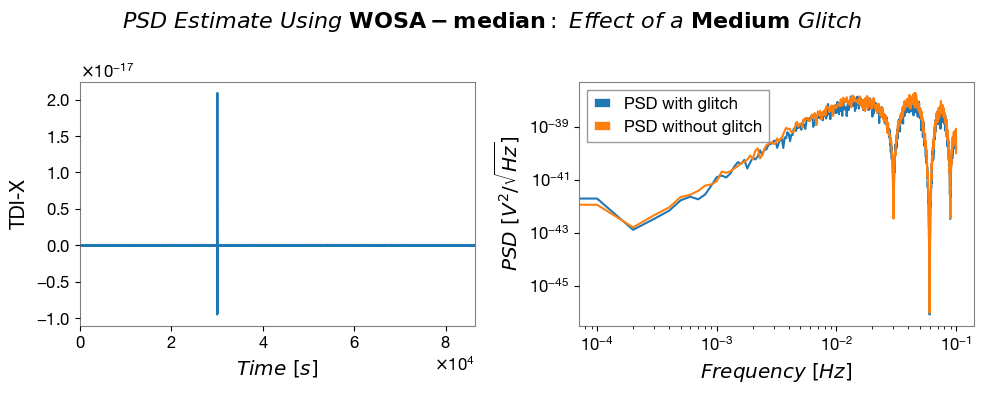

In [10]:
# 1) Read the TDI time series
tdi_path = getTdiPath('glitch_7.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 2000
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 

# Plot the original psd for no reason 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_median, psd_orig],
    labels= ["PSD with glitch", "PSD without glitch"],
    title="TDI-X", 
    # bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}"
    bigtitle=r"$PSD\ Estimate\ Using\ \mathbf{WOSA-median}:\ Effect\ of\ a\ \mathbf{Medium}\ Glitch$",
)

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

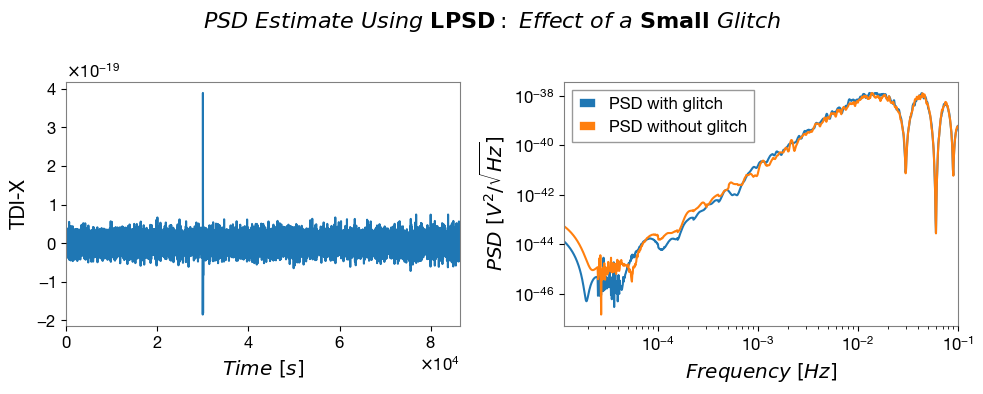

In [12]:
# 1) Read the TDI time series
tdi_path = getTdiPath('glitch_0.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 2000
f_lpsd, psd_lpsd, _, _ = lpsd(
    x=data,
    fs=fs
) 

# Plot the original psd for no reason 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_lpsd, 
    f_lims = [f_lpsd[0], fs/2.0],
    psd= [psd_lpsd, psd_orig_lpsd],
    labels= ["PSD with glitch", "PSD without glitch"],
    title="TDI-X", 
    bigtitle=r"$PSD\ Estimate\ Using\ \mathbf{LPSD}:\ Effect\ of\ a\ \mathbf{Small}\ Glitch$"
)

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

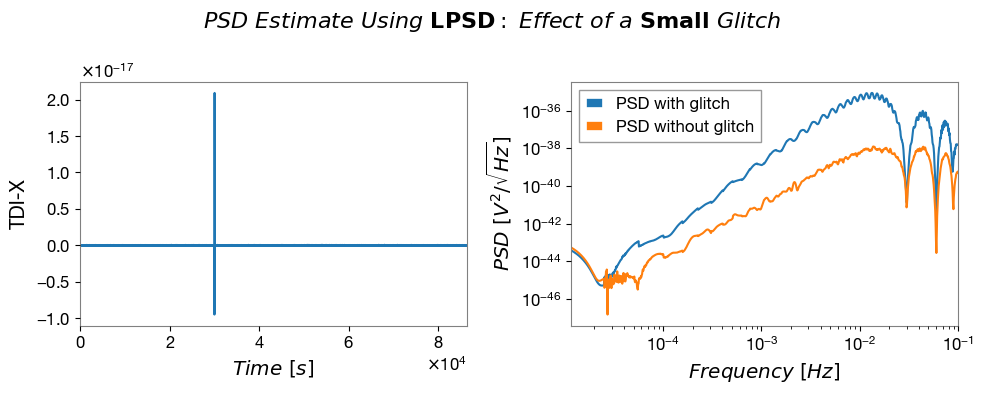

In [14]:
# 1) Read the TDI time series
tdi_path = getTdiPath('glitch_7.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 2000
f_lpsd, psd_lpsd, _, _ = lpsd(
    x=data,
    fs=fs
) 

# Plot the original psd for no reason 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_lpsd, 
    f_lims = [f_lpsd[0], fs/2.0],
    psd= [psd_lpsd, psd_orig_lpsd],
    labels= ["PSD with glitch", "PSD without glitch"],
    title="TDI-X", 
    bigtitle=r"$PSD\ Estimate\ Using\ \mathbf{LPSD}:\ Effect\ of\ a\ \mathbf{Small}\ Glitch$"
)

['L_1', 'L_1', '(0.6)^1 L_1', '(0.6)^2 L_1', '(0.6)^3 L_1', '(0.6)^4 L_1', '(0.6)^5 L_1', '(0.6)^6 L_1', '(0.6)^7 L_1', '(0.6)^8 L_1', '(0.6)^9 L_1', '(0.6)^10 L_1', '(0.6)^11 L_1', '(0.6)^12 L_1', '(0.6)^13 L_1', '(0.6)^14 L_1', '(0.6)^15 L_1']
Lk_list: [17280, 17280, 10368, 6220, 3732, 2239, 1343, 806, 483, 290, 174, 104, 62, 37, 22, 13]
fk_list: [4.6296296296296294e-05, 4.6296296296296294e-05, 7.716049382716049e-05, 0.00012861736334405144, 0.00021436227224008573, 0.0003573023671281822, 0.0005956813104988831, 0.0009925558312655087, 0.0016563146997929607, 0.002758620689655172, 0.004597701149425287, 0.007692307692307693, 0.012903225806451613, 0.021621621621621623, 0.03636363636363636, 0.06153846153846154]


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

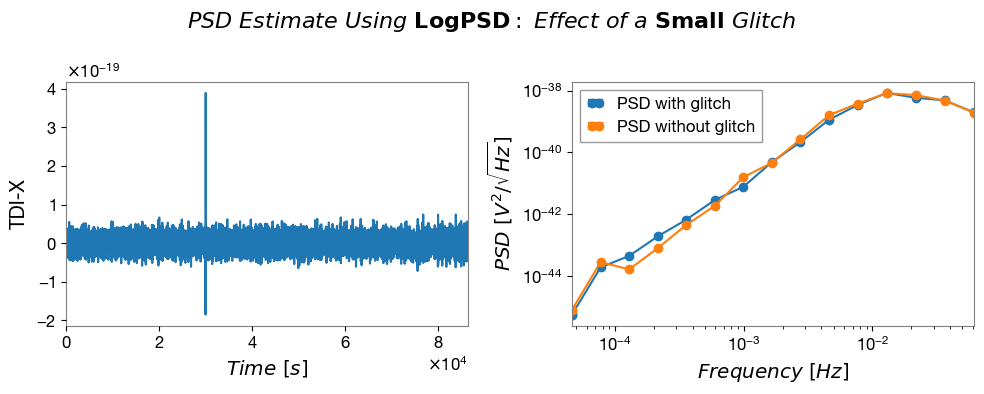

In [15]:
# 1) Read the TDI time series
tdi_path = getTdiPath('glitch_0.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 2000
f_logpsd, psd_logpsd, _ = logpsd(
    x=data,
    fs=fs,
    overlap=0, 
    L1=17280
) 

# Plot the original psd for no reason 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_logpsd, 
    psd= [psd_orig_logpsd, psd_logpsd],
    labels= ["PSD with glitch", "PSD without glitch"],
    title="TDI-X", 
    f_lims = [f_logpsd[0], f_logpsd[-1]],
    bigtitle=r"$PSD\ Estimate\ Using\ \mathbf{LogPSD}:\ Effect\ of\ a\ \mathbf{Small}\ Glitch$",
    logpsd = True
)

['L_1', 'L_1', '(0.6)^1 L_1', '(0.6)^2 L_1', '(0.6)^3 L_1', '(0.6)^4 L_1', '(0.6)^5 L_1', '(0.6)^6 L_1', '(0.6)^7 L_1', '(0.6)^8 L_1', '(0.6)^9 L_1', '(0.6)^10 L_1', '(0.6)^11 L_1', '(0.6)^12 L_1', '(0.6)^13 L_1', '(0.6)^14 L_1', '(0.6)^15 L_1']
Lk_list: [17280, 17280, 10368, 6220, 3732, 2239, 1343, 806, 483, 290, 174, 104, 62, 37, 22, 13]
fk_list: [4.6296296296296294e-05, 4.6296296296296294e-05, 7.716049382716049e-05, 0.00012861736334405144, 0.00021436227224008573, 0.0003573023671281822, 0.0005956813104988831, 0.0009925558312655087, 0.0016563146997929607, 0.002758620689655172, 0.004597701149425287, 0.007692307692307693, 0.012903225806451613, 0.021621621621621623, 0.03636363636363636, 0.06153846153846154]


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

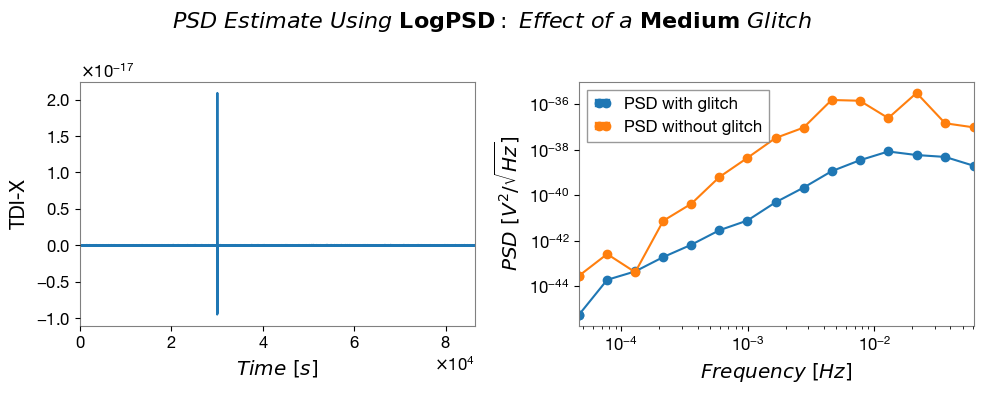

In [ ]:
# 1) Read the TDI time series
tdi_path = getTdiPath('glitch_7.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 2000
f_logpsd, psd_logpsd, _ = logpsd(
    x=data,
    fs=fs,
    overlap=0, 
    L1=17280
) 

# Plot the original psd for no reason 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_logpsd, 
    psd= [psd_orig_logpsd, psd_logpsd],
    labels= ["PSD with glitch", "PSD without glitch"],
    title="TDI-X", 
    f_lims = [f_logpsd[0], f_logpsd[-1]],
    bigtitle=r"$PSD\ Estimate\ Using\ \mathbf{LogPSD}:\ Effect\ of\ a\ \mathbf{Medium}\ Glitch$",
    logpsd = True
)

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

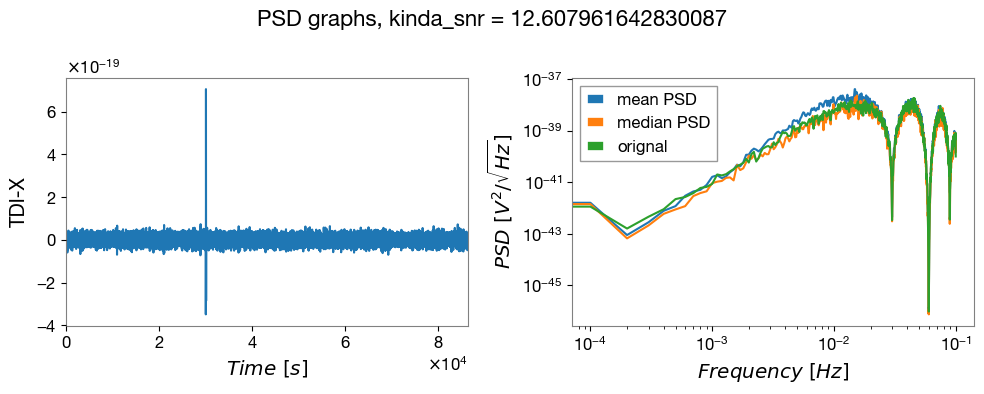

In [17]:
tdi_path = getTdiPath('glitch_2.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}"
)

/Users/akmdgreat/anaconda3/envs/bethenv/lib/python3.11/site-packages/gwpy/plot/axes.py:78: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  return func(self, **kw)


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

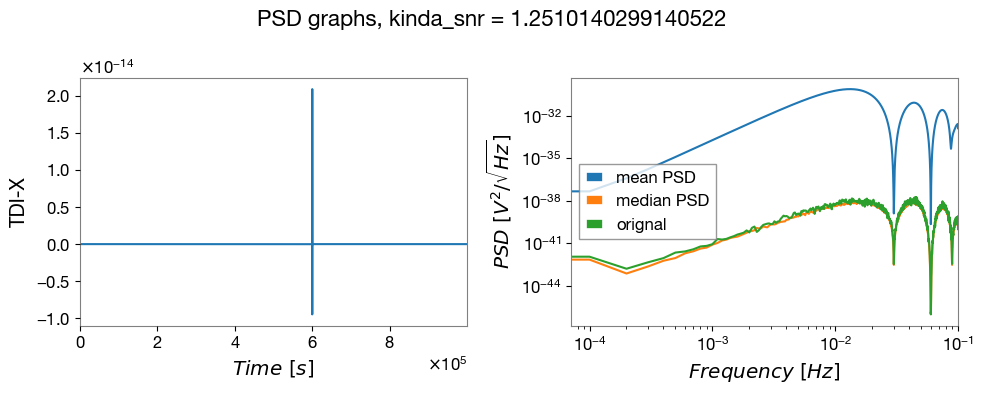

In [21]:
tdi_path = getTdiPath('glitch_9.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}",
    f_lims = [f_mean[0], f_mean[-1]]
)

In [1]:
f_orig, psd_orig, _, _ = wosa(
    x=data_orig,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

tdi_path = getTdiPath('glitch_9.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_orig],
    labels= ["mean PSD", "no glitch"],
    title="TDI-X", 
    f_lims = [f_mean[0], f_mean[-1]]
)

NameError: name 'wosa' is not defined

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

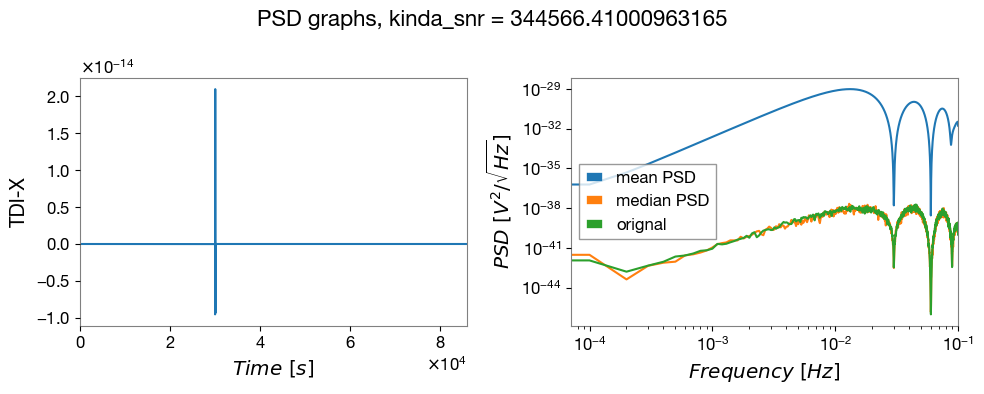

In [22]:
tdi_path = getTdiPath('glitch_9_one_day.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}",
    f_lims = [f_mean[0], f_mean[-1]]
)

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

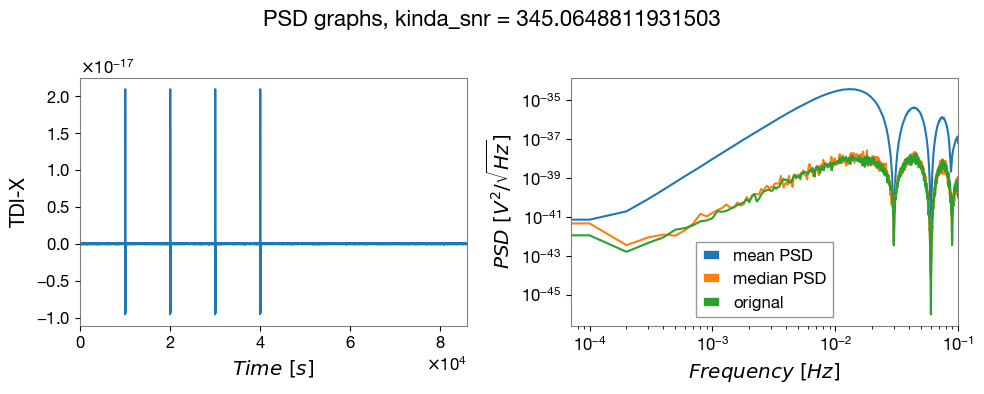

In [24]:
tdi_path = getTdiPath('glitch_7_multiple.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}",
    f_lims = [f_mean[0], f_mean[-1]]
)

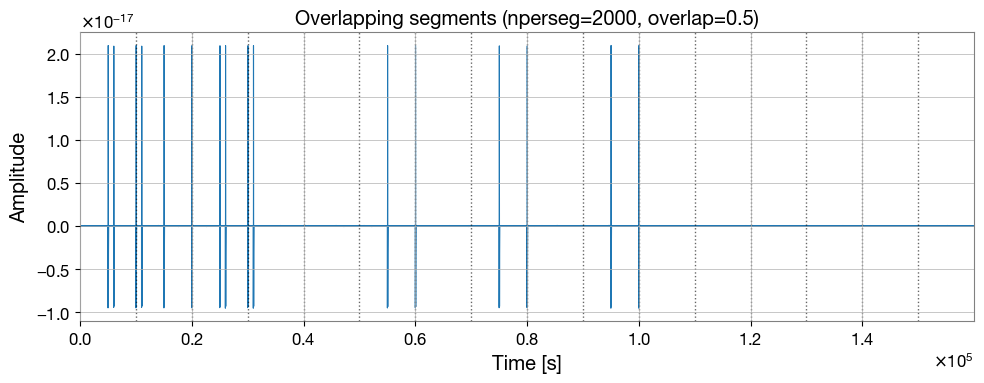

In [29]:
tdi_path = getTdiPath('glitch_7_multiple_7.h5')
data, fs, t = readTdi(tdi_path)
fig, ax = plot_segments(data, nperseg=2000, overlap=0.5, t=t, fs=fs)
plt.show()

/Users/akmdgreat/anaconda3/envs/bethenv/lib/python3.11/site-packages/gwpy/plot/axes.py:78: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  return func(self, **kw)


Number of segments = 16


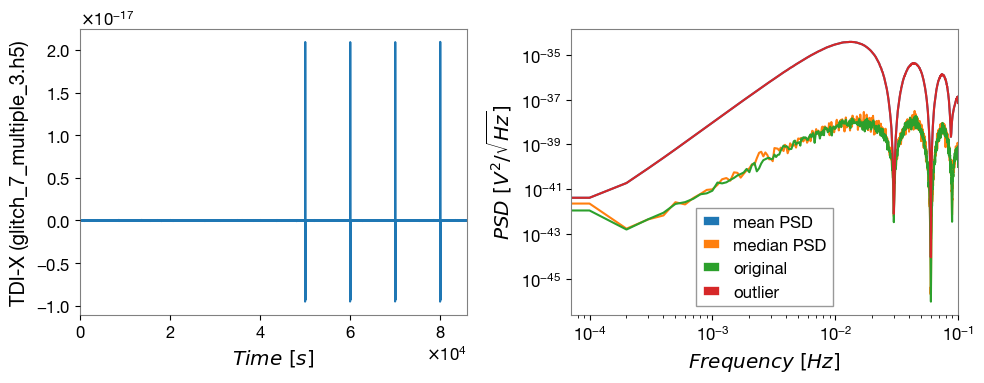

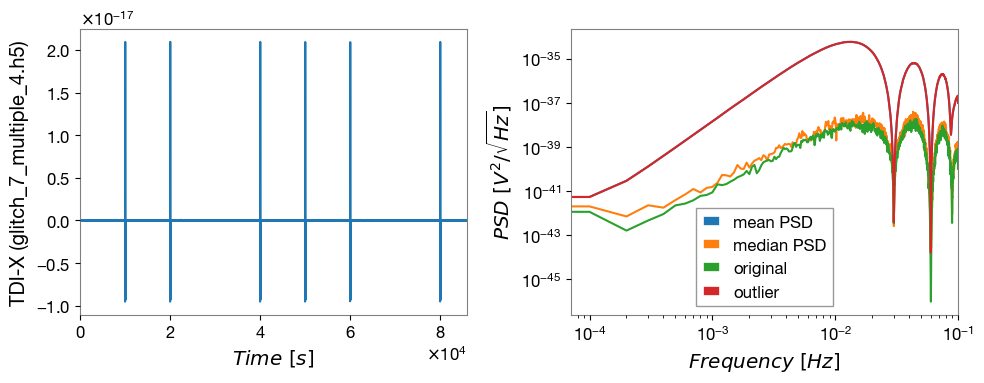

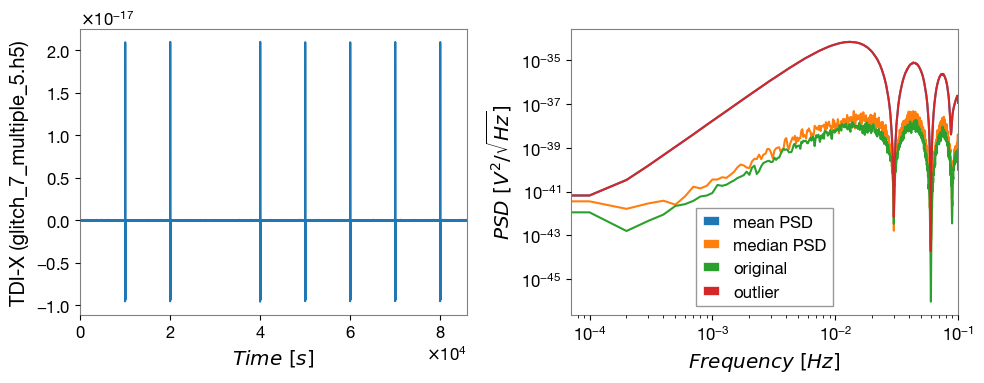

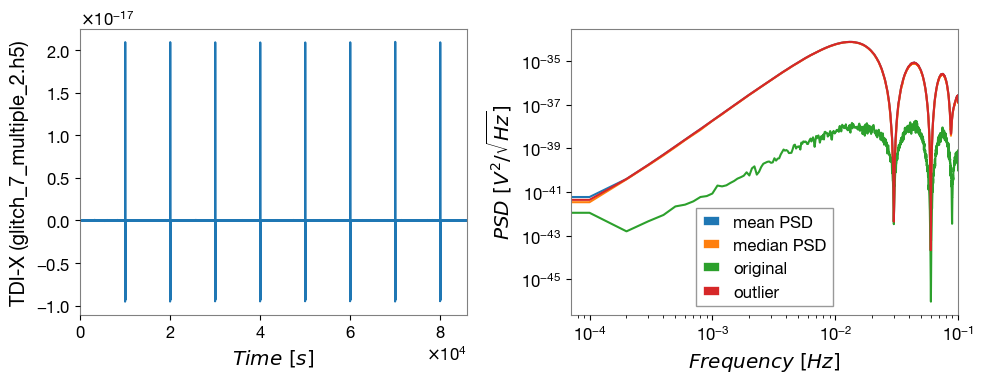

['L_1', 'L_1', '(0.6)^1 L_1', '(0.6)^2 L_1', '(0.6)^3 L_1', '(0.6)^4 L_1', '(0.6)^5 L_1', '(0.6)^6 L_1', '(0.6)^7 L_1', '(0.6)^8 L_1', '(0.6)^9 L_1', '(0.6)^10 L_1', '(0.6)^11 L_1', '(0.6)^12 L_1', '(0.6)^13 L_1', '(0.6)^14 L_1', '(0.6)^15 L_1']
Lk_list: [17000, 17000, 10200, 6120, 3671, 2203, 1321, 793, 475, 285, 171, 102, 61, 37, 22, 13]
fk_list: [4.705882352941177e-05, 4.705882352941177e-05, 7.843137254901961e-05, 0.00013071895424836603, 0.00021792427131571779, 0.00036314117113027687, 0.0006056018168054504, 0.001008827238335435, 0.0016842105263157896, 0.002807017543859649, 0.004678362573099415, 0.00784313725490196, 0.013114754098360656, 0.021621621621621623, 0.03636363636363636, 0.06153846153846154]
['L_1', 'L_1', '(0.6)^1 L_1', '(0.6)^2 L_1', '(0.6)^3 L_1', '(0.6)^4 L_1', '(0.6)^5 L_1', '(0.6)^6 L_1', '(0.6)^7 L_1', '(0.6)^8 L_1', '(0.6)^9 L_1', '(0.6)^10 L_1', '(0.6)^11 L_1', '(0.6)^12 L_1', '(0.6)^13 L_1', '(0.6)^14 L_1', '(0.6)^15 L_1']
Lk_list: [17000, 17000, 10200, 6120, 3671,

/Users/akmdgreat/anaconda3/envs/bethenv/lib/python3.11/site-packages/gwpy/plot/axes.py:78: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  return func(self, **kw)


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

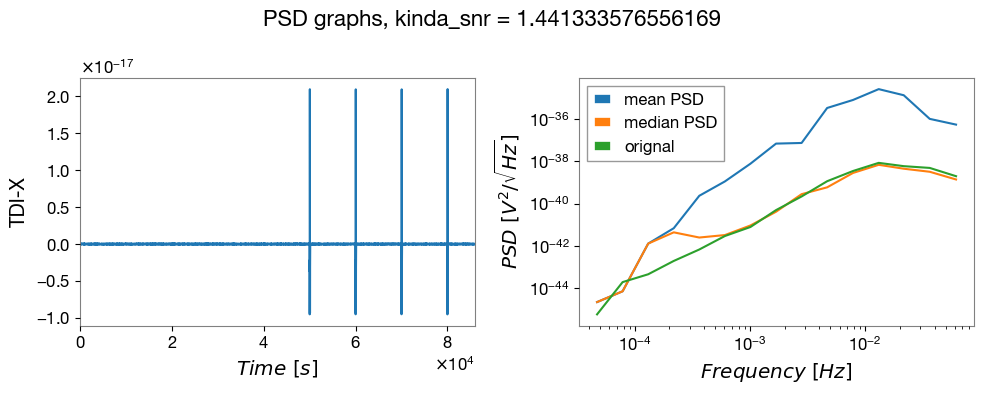

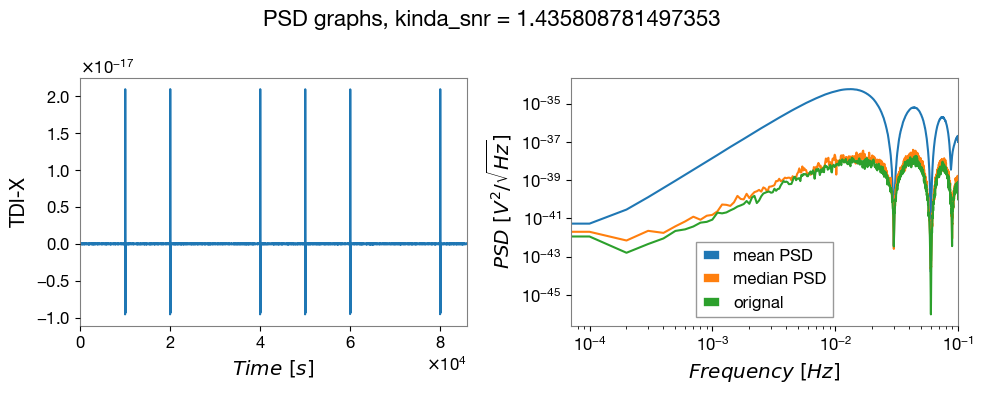

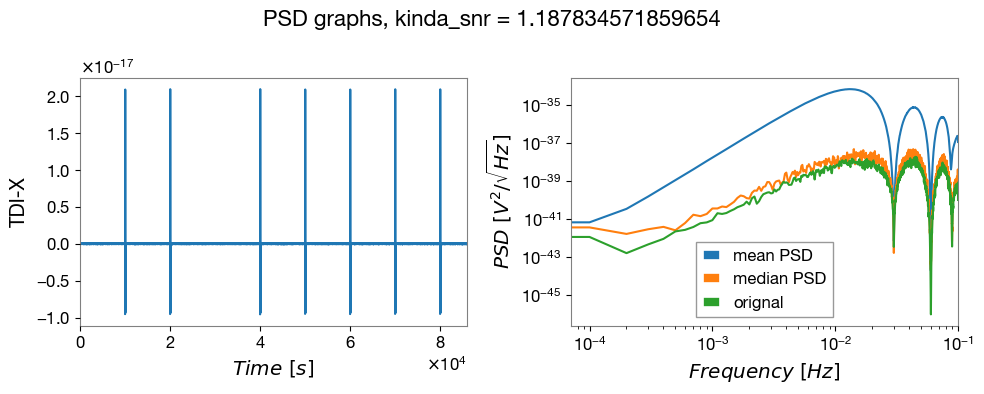

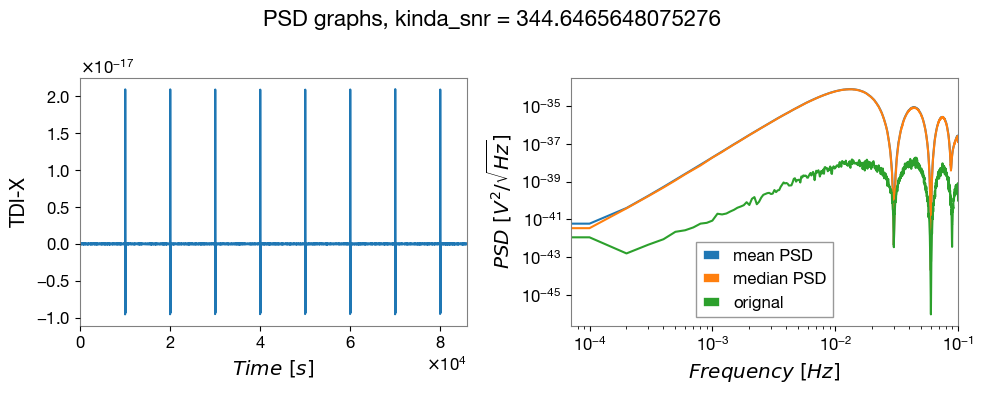

In [12]:

##################################

tdi_path = getTdiPath('glitch_7_multiple_3.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_logpsd, psd_logpsd, _ = logpsd(
    x=data,
    fs=fs,
    overlap=0, 
    L1=17000
) 
f_logpsd_median, psd_logpsd_median, _ = logpsd(
    x=data,
    fs=fs,
    overlap=0, 
    L1=17000, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_logpsd, 
    psd= [psd_logpsd, psd_logpsd_median, psd_orig_logpsd],
    labels= ["mean PSD", "median PSD", "orignal", "outlier rej"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}"
)


#####################################

tdi_path = getTdiPath('glitch_7_multiple_4.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}",
    f_lims = [f_mean[0], f_mean[-1]]
)



#####################################
tdi_path = getTdiPath('glitch_7_multiple_5.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}",
    f_lims = [f_mean[0], f_mean[-1]]
)


############################
tdi_path = getTdiPath('glitch_7_multiple_2.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}",
    f_lims = [f_mean[0], f_mean[-1]]
)


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: title={'center': 'Time series'}, xlabel='Time [s]', ylabel='TDI-X'>,
        <Axes: xlabel='Frequency [Hz]', ylabel='PSD (LISA)'>],
       dtype=object))

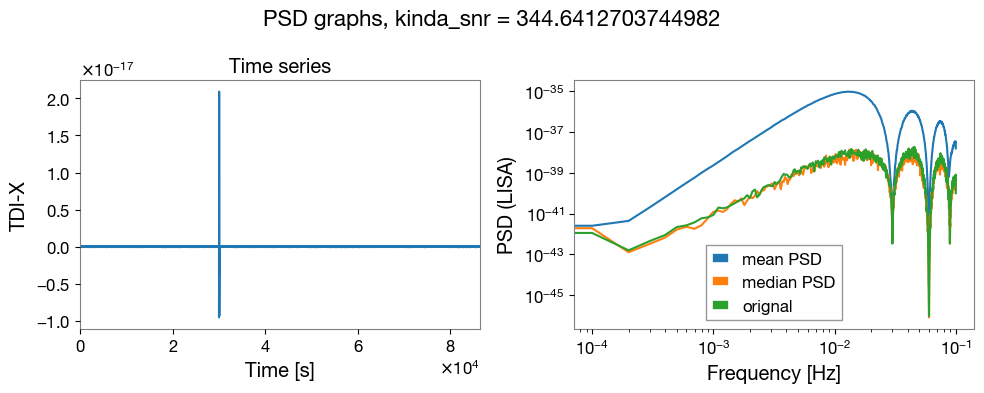

In [ ]:
tdi_path = getTdiPath('glitch_7.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    fs=fs, 
    f=f_mean, 
    nper=nperseg, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}"
)